# Safety Shield Synthesis on FrozenLake

This tutorial shows how to use `experiments.utils.shield_utils` to synthesise safety shields for tabular Gymnasium environments.

We use the local MASA-style `CustomFrozenLake-v0` environment because it exposes a tabular transition matrix, labels, and costs. The same utility functions work for any Gymnasium environment where you can provide those pieces.

The notebook covers:

1. an almost-sure deterministic shield on deterministic FrozenLake,
2. an almost-sure deterministic shield on slippery FrozenLake,
3. a probabilistic shield on slippery FrozenLake with a configurable risk threshold,
4. plotting safe state-action pairs as arrows over the rendered grid frame.

## Imports

The tutorial uses the local utility module directly. We set `use_masa_helper=False` in the
examples below purely so they remain runnable without the `MASA-Safe-RL` package installed -
production pipelines (`experiments/pipelines/safety/*`) leave `use_masa_helper` at its default
of `True` and synthesise shields through the real MASA library
(`masa.prob_shield.helpers.build_successor_states_matrix`), falling back to the local
implementation only when MASA isn't installed.

**Scope note:** shield synthesis here is exact tabular value iteration - it requires a fully
enumerated transition matrix `P(s'|s,a)` up front and is **not** applicable to continuous or
image-observation ("non-tabular") environments without a different algorithm (e.g. fitted/neural
value iteration over sampled transitions). See the `shield_utils` module docstring for details;
extending to non-tabular environments is tracked as separate future work.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path("/vol/bitbucket/ma5923/_projects/CertifiedContinualLearning")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import experiments.utils.masa_tabular_envs  # registers Custom* env IDs
from experiments.utils.masa_tabular_envs.factory import make_custom_masa_env
from experiments.utils.shield_utils import (
    ShieldSynthesisInfo,
    synthesise_deterministic_shield,
    synthesise_probabilistic_shield,
)

I0000 00:00:1780674790.011126  511466 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780674790.093417  511466 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780674797.059911  511466 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## A FrozenLake Safety Task

Holes are unsafe. The environment's built-in `label_fn` labels each state as `start`, `frozen`, `hole`, or `goal`; its `cost_fn` assigns cost `1.0` to holes and `0.0` elsewhere.

The shield utilities expect a transition-matrix function with the convention:

```python
P[s_next, s, a] = Pr(s_next | s, a)
```

In [2]:
DESC = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG",
]


def transition_matrix_fn(unwrapped_env) -> np.ndarray:
    return unwrapped_env.get_transition_matrix()


def shield_inputs(env):
    unwrapped = env.unwrapped
    return transition_matrix_fn, unwrapped.label_fn, unwrapped.cost_fn


deterministic_env = make_custom_masa_env(
    "CustomFrozenLake-v0",
    env_kwargs={"desc": DESC, "is_slippery": False},
    render_mode="rgb_array",
)

slippery_env = make_custom_masa_env(
    "CustomFrozenLake-v0",
    env_kwargs={"desc": DESC, "is_slippery": True, "success_rate": 1.0 / 3.0},
    render_mode="rgb_array",
)

deterministic_env.reset(seed=0)
slippery_env.reset(seed=0)

print("Deterministic transition matrix:", deterministic_env.unwrapped.get_transition_matrix().shape)
print("Slippery transition matrix:", slippery_env.unwrapped.get_transition_matrix().shape)

Deterministic transition matrix: (16, 16, 4)
Slippery transition matrix: (16, 16, 4)


## Plotting Helpers

The plotting function renders the grid frame, then draws one arrow per allowed state-action pair. Unsafe holes are left without arrows because the shield masks all actions there.

In [12]:
ACTION_NAMES = {
    0: "left",
    1: "down",
    2: "right",
    3: "up",
}

ACTION_DELTAS = {
    0: (-0.30, 0.00),
    1: (0.00, 0.30),
    2: (0.30, 0.00),
    3: (0.00, -0.30),
}


def render_frozen_lake_frame(env) -> np.ndarray:
    try:
        frame = env.render()
        if isinstance(frame, np.ndarray):
            return frame
    except Exception as exc:
        print(f"Falling back to a synthetic grid frame because render() failed: {exc}")

    desc = env.unwrapped.desc
    nrow, ncol = desc.shape
    cell_px = 96
    frame = np.zeros((nrow * cell_px, ncol * cell_px, 3), dtype=np.uint8)
    palette = {
        "S": np.array([196, 230, 255], dtype=np.uint8),
        "F": np.array([235, 248, 255], dtype=np.uint8),
        "H": np.array([35, 55, 75], dtype=np.uint8),
        "G": np.array([190, 245, 205], dtype=np.uint8),
    }
    for row in range(nrow):
        for col in range(ncol):
            cell = desc[row, col]
            cell = cell.decode("utf-8") if isinstance(cell, bytes | np.bytes_) else str(cell)
            y0, y1 = row * cell_px, (row + 1) * cell_px
            x0, x1 = col * cell_px, (col + 1) * cell_px
            frame[y0:y1, x0:x1] = palette[cell]
            frame[y0:y0 + 2, x0:x1] = 255
            frame[y1 - 2:y1, x0:x1] = 255
            frame[y0:y1, x0:x0 + 2] = 255
            frame[y0:y1, x1 - 2:x1] = 255
    return frame


def plot_shield_on_frozen_lake(
    env,
    shield: np.ndarray,
    title: str,
    *,
    info: ShieldSynthesisInfo | None = None,
    show_risk: bool = False,
    ax=None,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4.5))

    frame = render_frozen_lake_frame(env)
    ax.imshow(frame)
    ax.set_title(title)
    ax.axis("off")

    nrow = int(env.unwrapped.nrow)
    ncol = int(env.unwrapped.ncol)
    height, width = frame.shape[:2]
    cell_w = width / ncol
    cell_h = height / nrow

    for state, action in np.argwhere(shield == 1):
        row, col = divmod(int(state), ncol)
        cx = (col + 0.5) * cell_w
        cy = (row + 0.5) * cell_h
        dx, dy = ACTION_DELTAS[int(action)]

        risk = None
        if info is not None and info.action_risk is not None:
            risk = float(info.action_risk[int(state), int(action)])

        color = "#0f766e"
        if show_risk and risk is not None:
            color = plt.cm.RdYlGn_r(np.clip(risk, 0.0, 1.0))

        ax.annotate(
            "",
            xy=(cx + dx * cell_w, cy + dy * cell_h),
            xytext=(cx, cy),
            arrowprops={"arrowstyle": "-|>", "color": color, "lw": 2.4, "alpha": 0.95},
        )

        if show_risk and risk is not None and risk > 0.0:
            ax.text(
                cx + dx * cell_w * 1.12,
                cy + dy * cell_h * 1.12,
                f"{risk:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                bbox={"boxstyle": "round,pad=0.12", "fc": "white", "ec": "none", "alpha": 0.75},
            )

    return ax


def print_allowed_actions(env, shield: np.ndarray) -> None:
    ncol = int(env.unwrapped.ncol)
    for state in range(shield.shape[0]):
        allowed = [ACTION_NAMES[int(action)] for action in np.flatnonzero(shield[state])]
        if not allowed:
            continue
        row, col = divmod(state, ncol)
        labels = sorted(env.unwrapped.label_fn(state))
        print(f"state {state:2d} at ({row}, {col}) labels={labels}: {allowed}")

## 1. Deterministic Dynamics, Deterministic Shield

In the non-slippery environment, every action has a single successor. The deterministic shield therefore allows actions that stay inside the almost-sure winning set.

Deterministic FrozenLake shield shape: (16, 4)
Winning states: [0, 1, 2, 3, 4, 6, 8, 9, 10, 13, 14, 15]
state  0 at (0, 0) labels=['start']: ['left', 'down', 'right', 'up']
state  1 at (0, 1) labels=['frozen']: ['left', 'right', 'up']
state  2 at (0, 2) labels=['frozen']: ['left', 'down', 'right', 'up']
state  3 at (0, 3) labels=['frozen']: ['left', 'right', 'up']
state  4 at (1, 0) labels=['frozen']: ['left', 'down', 'up']
state  6 at (1, 2) labels=['frozen']: ['down', 'up']
state  8 at (2, 0) labels=['frozen']: ['left', 'right', 'up']
state  9 at (2, 1) labels=['frozen']: ['left', 'down', 'right']
state 10 at (2, 2) labels=['frozen']: ['left', 'down', 'up']
state 13 at (3, 1) labels=['frozen']: ['down', 'right', 'up']
state 14 at (3, 2) labels=['frozen']: ['left', 'down', 'right', 'up']
state 15 at (3, 3) labels=['goal']: ['left', 'down', 'right', 'up']


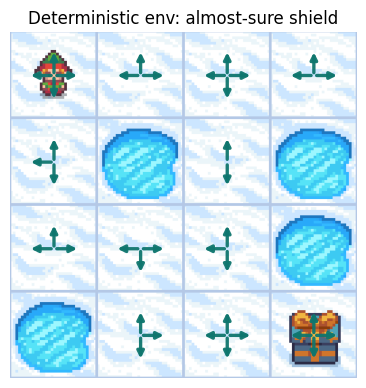

In [13]:
det_transition_matrix_fn, det_label_fn, det_cost_fn = shield_inputs(deterministic_env)

det_shield, det_info = synthesise_deterministic_shield(
    deterministic_env,
    det_transition_matrix_fn,
    det_label_fn,
    det_cost_fn,
    use_masa_helper=False,
    return_info=True,
)

print("Deterministic FrozenLake shield shape:", det_shield.shape)
print("Winning states:", det_info.winning_states.tolist())
print_allowed_actions(deterministic_env, det_shield)

plot_shield_on_frozen_lake(
    deterministic_env,
    det_shield,
    "Deterministic env: almost-sure shield",
    info=det_info,
);
plt.show()

## 2. Slippery Dynamics, Deterministic Shield

The same almost-sure rule can be applied to stochastic dynamics. It is stricter here: an action is allowed only if every successor with nonzero probability is still in the winning set.

Slippery FrozenLake deterministic shield shape: (16, 4)
Winning states: [0, 1, 2, 3, 15]
state  0 at (0, 0) labels=['start']: ['up']
state  1 at (0, 1) labels=['frozen']: ['up']
state  2 at (0, 2) labels=['frozen']: ['up']
state  3 at (0, 3) labels=['frozen']: ['up']
state 15 at (3, 3) labels=['goal']: ['left', 'down', 'right', 'up']


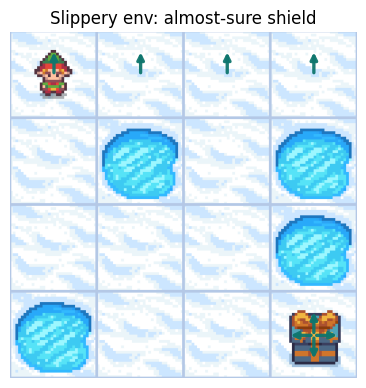

In [14]:
slip_transition_matrix_fn, slip_label_fn, slip_cost_fn = shield_inputs(slippery_env)

slip_det_shield, slip_det_info = synthesise_deterministic_shield(
    slippery_env,
    slip_transition_matrix_fn,
    slip_label_fn,
    slip_cost_fn,
    use_masa_helper=False,
    return_info=True,
)

print("Slippery FrozenLake deterministic shield shape:", slip_det_shield.shape)
print("Winning states:", slip_det_info.winning_states.tolist())
print_allowed_actions(slippery_env, slip_det_shield)

plot_shield_on_frozen_lake(
    slippery_env,
    slip_det_shield,
    "Slippery env: almost-sure shield",
    info=slip_det_info,
);
plt.show()

## 3. Slippery Dynamics, Probabilistic Shield

The probabilistic shield estimates the eventual probability of reaching a hole after taking each action, assuming future actions are chosen optimally for safety. Actions whose conservative risk is at most `risk_threshold` are allowed.

Here `risk_threshold=0.35` permits some controlled slip risk while still blocking high-risk actions. The small numbers printed next to arrows are the conservative action risks.

Slippery FrozenLake probabilistic shield shape: (16, 4)
Value-iteration steps: 219
Value-iteration residual: 9.003214840319629e-13
state  0 at (0, 0) labels=['start']: ['left', 'down', 'right', 'up']
state  1 at (0, 1) labels=['frozen']: ['left', 'down', 'right', 'up']
state  2 at (0, 2) labels=['frozen']: ['left', 'down', 'right', 'up']
state  3 at (0, 3) labels=['frozen']: ['left', 'down', 'right', 'up']
state  4 at (1, 0) labels=['frozen']: ['left', 'down', 'right', 'up']
state  6 at (1, 2) labels=['frozen']: ['left', 'right']
state  8 at (2, 0) labels=['frozen']: ['left', 'down', 'right', 'up']
state  9 at (2, 1) labels=['frozen']: ['left', 'down']
state 10 at (2, 2) labels=['frozen']: ['left', 'down']
state 13 at (3, 1) labels=['frozen']: ['left', 'down', 'right', 'up']
state 14 at (3, 2) labels=['frozen']: ['left', 'down', 'right', 'up']
state 15 at (3, 3) labels=['goal']: ['left', 'down', 'right', 'up']


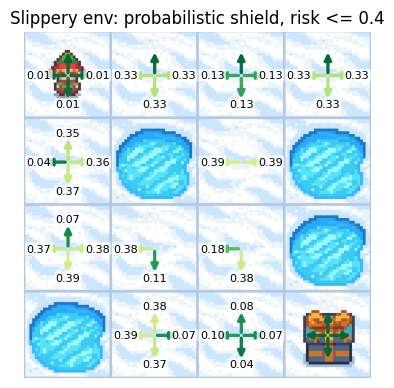

In [17]:
RISK_THRESHOLD = 0.4

slip_prob_shield, slip_prob_info = synthesise_probabilistic_shield(
    slippery_env,
    slip_transition_matrix_fn,
    slip_label_fn,
    slip_cost_fn,
    risk_threshold=RISK_THRESHOLD,
    theta=1e-12,
    max_vi_steps=10_000,
    use_masa_helper=False,
    return_info=True,
)

print("Slippery FrozenLake probabilistic shield shape:", slip_prob_shield.shape)
print("Value-iteration steps:", slip_prob_info.vi_steps)
print("Value-iteration residual:", slip_prob_info.vi_residual)
print_allowed_actions(slippery_env, slip_prob_shield)

plot_shield_on_frozen_lake(
    slippery_env,
    slip_prob_shield,
    f"Slippery env: probabilistic shield, risk <= {RISK_THRESHOLD}",
    info=slip_prob_info,
    show_risk=True,
);
plt.show()

## Side-by-side Comparison

The three plots below compare how the allowed action set changes as we move from deterministic dynamics to stochastic dynamics, and then from almost-sure shielding to risk-thresholded shielding.

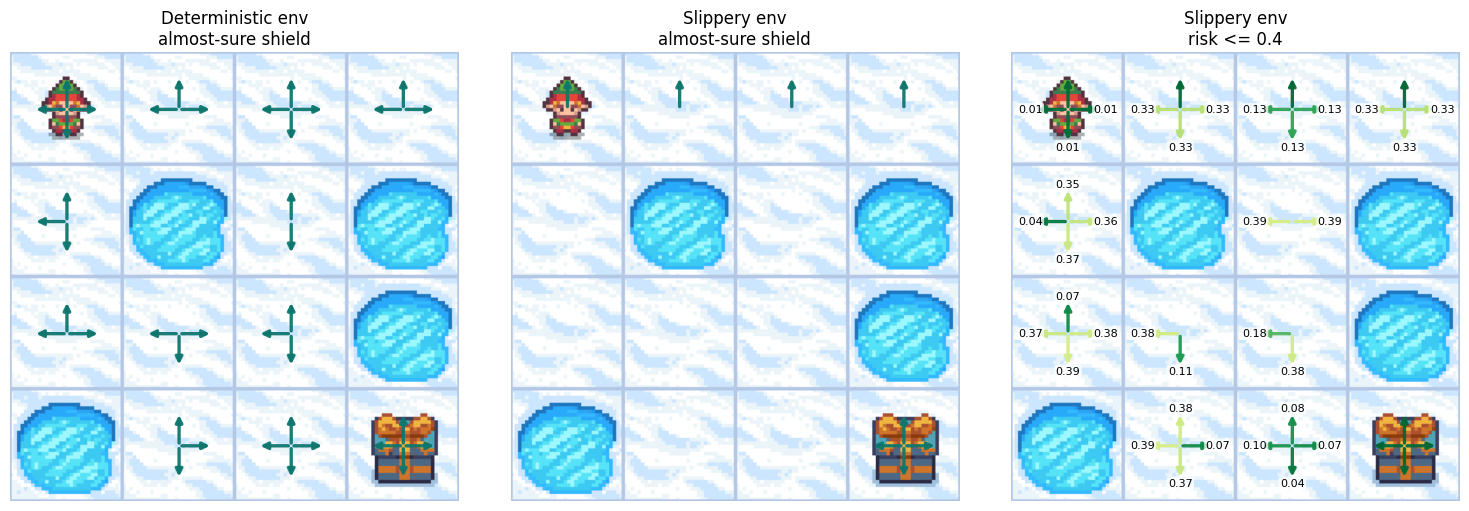

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_shield_on_frozen_lake(
    deterministic_env,
    det_shield,
    "Deterministic env\nalmost-sure shield",
    info=det_info,
    ax=axes[0],
)
plot_shield_on_frozen_lake(
    slippery_env,
    slip_det_shield,
    "Slippery env\nalmost-sure shield",
    info=slip_det_info,
    ax=axes[1],
)
plot_shield_on_frozen_lake(
    slippery_env,
    slip_prob_shield,
    f"Slippery env\nrisk <= {RISK_THRESHOLD}",
    info=slip_prob_info,
    show_risk=True,
    ax=axes[2],
)

plt.show()

## Using the Shield as an Action Mask

At training or evaluation time, the shield is just a binary matrix. Given tabular state `s`, the allowed actions are:

In [19]:
state = 0
allowed_actions = np.flatnonzero(slip_prob_shield[state])
print("Allowed actions from state", state, ":", [ACTION_NAMES[int(action)] for action in allowed_actions])

# Example: mask policy logits before sampling.
policy_logits = np.array([0.3, 0.1, 0.4, 0.2], dtype=np.float64)
masked_logits = policy_logits.copy()
masked_logits[slip_prob_shield[state] == 0] = -np.inf
print("Original logits:", policy_logits)
print("Masked logits:", masked_logits)

Allowed actions from state 0 : ['left', 'down', 'right', 'up']
Original logits: [0.3 0.1 0.4 0.2]
Masked logits: [0.3 0.1 0.4 0.2]


## Cleanup

In [20]:
deterministic_env.close()
slippery_env.close()